# 04 — Drift Analysis

Computes **all drift metrics** from Chapter 3 of the thesis for each window pair (A, B) across all supported model types, then produces a combined temporal dashboard.

**Model types:** `MODEL_TYPES = ['xgboost', 'logreg']`  
Artifacts are read from `data/models/{model_type}/` and `data/shap/{model_type}/`.

**Input:** `data/processed/`, `data/windows/`, `data/models/{model_type}/`, `data/shap/{model_type}/`  
**Output per model type:** `data/results/{model_type}/drift_metrics.csv`  
**Combined outputs:** `data/results/combined/drift_metrics_combined.csv`, `data/results/combined/temporal_drift_report.png`

---

| Metric | Symbol | Section | XGBoost | LR |
|--------|--------|---------|---------|-----|
| Covariate drift | Δ_X | §3.2 | ✓ | ✓ |
| Target drift | Δ_Y | §3.2 | ✓ | ✓ |
| Performance change | Δ_perf | §3.2 | ✓ | ✓ |
| Local dynamic drift (cosine) | Δ_E^{loc}(cos) | §3.5 | SHAP-based | coeff-vector-based |
| Local dynamic drift (RBO) | Δ_E^{loc}(rbo) | §3.5 | SHAP-based | coeff-vector-based |
| Within-window baseline (cosine) | σ_E^{pool}(cos) | §3.6 | SHAP-based | coeff-vector-based |
| Within-window baseline (RBO) | σ_E^{pool}(rbo) | §3.6 | SHAP-based | coeff-vector-based |
| Drift Ratio (cosine) | DR_cos | §3.7 | ✓ | ✓ |
| Drift Ratio (RBO) | DR_rbo | §3.7 | ✓ | ✓ |
| Global drift | Δ_E^{glob} | §3.8 | SHAP ranking | \|coef\| ranking |
| Explainer stochasticity | — | §3.9 | ✓ | NaN |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> **Setup note:** this notebook requires the `rbo` package for rank-biased overlap metrics (§3.5, §3.8).  
> If not already installed, run: `pip install rbo`

In [4]:
%pip install rbo

In [ ]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
from itertools import combinations
import rbo

WORKSPACE  = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
PROC_DIR   = WORKSPACE / 'data' / 'processed'
WIN_DIR    = WORKSPACE / 'data' / 'windows'

# ── Per-model-type base directories ───────────────────────────────────
MODEL_DIR_BASE   = WORKSPACE / 'data' / 'models'
SHAP_DIR_BASE    = WORKSPACE / 'data' / 'shap'
RESULTS_DIR_BASE = WORKSPACE / 'data' / 'results'

# Aliases used by downstream cells (per-feature plot; summary stats)
SHAP_DIR    = SHAP_DIR_BASE    / 'xgboost'   # XGBoost SHAP only
RESULTS_DIR = RESULTS_DIR_BASE               # backwards compat alias

COMBINED_DIR = RESULTS_DIR_BASE / 'combined'
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

MODEL_TYPES = ['xgboost', 'logreg']   # model types to process

RBO_P = 0.9   # persistence parameter for RBO
EPS   = 1e-8  # small constant for Drift Ratio denominator

print('Imports OK')
print(f'MODEL_TYPES: {MODEL_TYPES}')

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
X    = pd.read_parquet(PROC_DIR / 'X.parquet').values.astype(np.float32)
Y    = np.load(PROC_DIR / 'Y.npy').astype(np.int8)

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)
feature_names     = feature_names_json['all']   # flat list, 119 names in column order
num_feature_names = feature_names_json['num']   # 113 numeric feature names

# Column indices of numeric / binary features in X (column order matches feature_names)
num_col_idx = [feature_names.index(fn) for fn in num_feature_names]
bin_col_idx = [i for i in range(len(feature_names)) if i not in set(num_col_idx)]

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']
n_features = len(feature_names)

print(f'X: {X.shape}, features: {n_features}, R={R}, pairs: {len(pairs)}')
print(f'  Numeric: {len(num_col_idx)}, Binary: {len(bin_col_idx)}')

X: (160057, 119), features: 119, R=8, pairs: 2
  Numeric: 113, Binary: 6


## Distance and RBO helper functions

In [ ]:
def cosine_distance(u: np.ndarray, v: np.ndarray) -> float:
    """d_cos(u,v) = 1 - cosine_similarity(u,v).
    Both-zero → 0.0; one-zero one-nonzero → np.nan (excluded by nanmedian aggregation).
    """
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u < 1e-12 and norm_v < 1e-12:
        return 0.0
    if norm_u < 1e-12 or norm_v < 1e-12:
        # One attribution vector is exactly zero; the other is not.
        # Not a meaningful distance — marked nan and dropped during aggregation.
        return np.nan
    return float(1.0 - np.dot(u, v) / (norm_u * norm_v))


def rbo_score_local(l1, l2, p=0.9):
    """Simple RBO implementation as fallback."""
    if not l1 or not l2: return 0.0
    n = min(len(l1), len(l2))
    s1, s2 = set(), set()
    agreement = 0.0
    res = 0.0
    for i in range(n):
        s1.add(l1[i])
        s2.add(l2[i])
        agreement = len(s1.intersection(s2)) / (i + 1)
        res += agreement * (p ** i)
    return res * (1 - p)


def rbo_distance(u: np.ndarray, v: np.ndarray, p: float = RBO_P) -> float:
    """
    d_rbo(u, v) = 1 - RBO(rank(u), rank(v)).
    Features are ranked by decreasing absolute attribution.
    Both-zero → 0.0; one-zero one-nonzero → np.nan.
    """
    u_zero = np.all(np.abs(u) < 1e-12)
    v_zero = np.all(np.abs(v) < 1e-12)
    if u_zero and v_zero:
        return 0.0
    if u_zero or v_zero:
        return np.nan
    rank_u = list(np.argsort(-np.abs(u)))
    rank_v = list(np.argsort(-np.abs(v)))
    
    if rbo is not None:
        score = rbo.RankingSimilarity(rank_u, rank_v).rbo(p=p)
    else:
        score = rbo_score_local(rank_u, rank_v, p=p)
        
    return float(1.0 - score)


def instance_dynamic_drift(
    phi_A: np.ndarray,  # (R, p) — R attribution vectors from window A
    phi_B: np.ndarray,  # (R, p) — R attribution vectors from window B
    dist_fn,
) -> float:
    """
    δ_dyn(x; d) = mean over all R×R cross-window pairs of d(φ_A^{(r)}, φ_B^{(s)}).
    """
    dists = []
    for r in range(R):
        for s in range(R):
            dists.append(dist_fn(phi_A[r], phi_B[s]))
    return float(np.nanmean(dists))


def instance_baseline_instability(
    phi: np.ndarray,  # (R, p) — R attribution vectors from same window
    dist_fn,
) -> float:
    """
    δ^{base}(x; d) = median over all r < r' pairs of d(φ^{(r)}, φ^{(r')}).
    """
    dists = []
    for r, r2 in combinations(range(R), 2):
        dists.append(dist_fn(phi[r], phi[r2]))
    return float(np.nanmedian(dists)) if dists else 0.0


def rbo_global_drift(
    phi_bar_A: np.ndarray,  # (|F|, p)
    phi_bar_B: np.ndarray,  # (|F|, p)
    p: float = RBO_P,
) -> float:
    """
    Δ_E^{glob}: 1 − RBO(rank(g_A), rank(g_B)) where g(j) = mean_x |φ̄_j(x)|.
    """
    g_A = np.abs(phi_bar_A).mean(axis=0)
    g_B = np.abs(phi_bar_B).mean(axis=0)
    rank_A = list(np.argsort(-g_A))
    rank_B = list(np.argsort(-g_B))
    
    if rbo is not None:
        score = rbo.RankingSimilarity(rank_A, rank_B).rbo(p=p)
    else:
        score = rbo_score_local(rank_A, rank_B, p=p)
        
    return float(1.0 - score)


print('Distance functions defined.')

Distance functions defined.


## Main drift computation loop

For each window pair we compute all metrics and append to a results list.

## Logistic Regression — coefficient-drift metric mapping

LR coefficients are the explanation (no post-hoc XAI). The table below documents which SHAP-based metrics have coefficient analogues and which do not.

| SHAP metric | LR analogue | Notes |
|---|---|---|
| Covariate drift Δ_X | ✓ identical | data-level, model-agnostic |
| Target drift Δ_Y | ✓ identical | data-level, model-agnostic |
| Performance change Δ_perf | ✓ identical | same PR-AUC formula |
| `loc_cos` / `loc_rbo` | mean `cosine_distance(coef_A[r], coef_B[s])` over R×R pairs | no per-instance dimension for LR |
| `base_cos_A/B`, `sigma_cos` | median `cosine_distance(coef[r], coef[r′])` over C(R,2) pairs per window | same formula, coefficient vectors as input |
| Drift Ratio | ✓ identical formula | |
| `global_rbo` | `1 − RBO(rank(|coef̄_A|), rank(|coef̄_B|))` | ranked by mean absolute coefficient |
| `shap_stochasticity` | NaN | LR coefficients are deterministic |

In [ ]:
all_results = {}

for mt in MODEL_TYPES:
    print(f'\n{"="*60}')
    print(f'  Model type: {mt}')
    print(f'{"="*60}')

    mt_model_dir = MODEL_DIR_BASE / mt
    mt_shap_dir  = SHAP_DIR_BASE  / mt
    results = []

    for p in pairs:
        pid      = p['pair_id']
        pair_dir = mt_model_dir / f'pair_{pid:02d}'
        shap_dir = mt_shap_dir  / f'pair_{pid:02d}'

        print(f'\n── [{mt}] Pair {pid:02d}: A_end={p["step_label_A"]}  B_end={p["step_label_B"]} ──')

        # Load predictions
        pred_data_path = pair_dir / 'predictions.npz'
        if not pred_data_path.exists():
            print(f'  WARNING: predictions.npz not found for pair {pid:02d}. Skipping.')
            continue
            
        pred_data = np.load(pred_data_path)
        idx_A    = np.array(p['idx_A'],    dtype=np.int64)
        idx_B    = np.array(p['idx_B'],    dtype=np.int64)
        idx_eval = np.array(p['idx_eval'], dtype=np.int64)
        flagged_local_idx = pred_data['flagged_idx']
        n_flagged = len(flagged_local_idx)
        print(f'  Flagged: {n_flagged:,}')

        row = {
            'model_type':    mt,
            'pair_id':       pid,
            'step_label_A':  p['step_label_A'],
            'step_label_B':  p['step_label_B'],
            'n_train_A':     p['n_train_A'],
            'n_train_B':     p['n_train_B'],
            'n_eval':        p['n_eval'],
            'n_flagged':     n_flagged,
            'pr_auc_A':      float(pred_data['pr_auc_A']),
            'pr_auc_B':      float(pred_data['pr_auc_B']),
        }

        # ── §3.2 Performance change ───────────────────────────────────────
        loss_A = 1.0 - float(pred_data['pr_auc_A'])
        loss_B = 1.0 - float(pred_data['pr_auc_B'])
        row['delta_perf'] = loss_A - loss_B

        # ── §3.2 Target drift ─────────────────────────────────────────────
        mean_Y_A = Y[idx_A].mean()
        mean_Y_B = Y[idx_B].mean()
        row['delta_Y'] = abs(mean_Y_A - mean_Y_B)
        print(f'  Target drift: {row["delta_Y"]:.4f}  (base rate A={mean_Y_A:.4f}, B={mean_Y_B:.4f})')

        # ── §3.2 Covariate drift ──────────────────────────────────────────
        X_A_raw = X[idx_A]
        X_B_raw = X[idx_B]
        reference_scaler_path = pair_dir / 'reference_scaler.joblib'
        if reference_scaler_path.exists():
            reference_scaler = joblib.load(reference_scaler_path)
        X_A_num_sc = reference_scaler.transform(X_A_raw[:, num_col_idx])
        X_B_num_sc = reference_scaler.transform(X_B_raw[:, num_col_idx])
        w1_per_feat = np.zeros(n_features, dtype=np.float64)
        for k, j in enumerate(num_col_idx):
            w1_per_feat[j] = wasserstein_distance(X_A_num_sc[:, k], X_B_num_sc[:, k])
        for j in bin_col_idx:
            w1_per_feat[j] = wasserstein_distance(X_A_raw[:, j], X_B_raw[:, j])
        row['delta_X'] = float(w1_per_feat.mean())
        print(f'  Covariate drift: {row["delta_X"]:.4f}')
        else:
            row['delta_X'] = np.nan
            print(f'  WARNING: reference_scaler.joblib not found for pair {pid:02d}')

        # ── §3.9 Explainer stochasticity ──────────────────────────────────
        if mt == 'xgboost':
            stoch_path = shap_dir / 'stochasticity.json'
            if stoch_path.exists():
                with open(stoch_path) as f:
                    stoch_data = json.load(f)
                row['shap_stochasticity'] = float(stoch_data['max_abs_diff'])
            else:
                row['shap_stochasticity'] = np.nan
                print(f'  WARNING: stochasticity.json not found for pair {pid:02d}')
        else:
            row['shap_stochasticity'] = np.nan

        # ── Model-type-specific drift metrics ─────────────────────────────
        if mt == 'xgboost':
            shap_A_path = shap_dir / 'shap_A.npy'
            shap_B_path = shap_dir / 'shap_B.npy'
            
            if not (shap_A_path.exists() and shap_B_path.exists()):
                print(f'  WARNING: SHAP files not found for pair {pid:02d}. Skipping specific drift metrics.')
                results.append(row)
                continue

            shap_A = np.load(shap_A_path)   # (R, |F|, p)
            shap_B = np.load(shap_B_path)

            if n_flagged == 0:
                for key in ['loc_cos', 'loc_rbo', 'base_cos_A', 'base_cos_B', 'base_rbo_A',
                            'base_rbo_B', 'sigma_cos', 'sigma_rbo',
                            'drift_ratio_cos', 'drift_ratio_rbo', 'global_rbo']:
                    row[key] = np.nan
                results.append(row)
                print('  No flagged instances — drift metrics set to NaN.')
                continue

            # §3.5 Dynamic cross-window drift
            dyn_cos_per_instance = []
            dyn_rbo_per_instance = []
            for i in range(n_flagged):
                phi_A_i = shap_A[:, i, :]
                phi_B_i = shap_B[:, i, :]
                dyn_cos_per_instance.append(instance_dynamic_drift(phi_A_i, phi_B_i, cosine_distance))
                dyn_rbo_per_instance.append(instance_dynamic_drift(phi_A_i, phi_B_i, rbo_distance))
            dyn_cos_arr = np.array(dyn_cos_per_instance)
            dyn_rbo_arr = np.array(dyn_rbo_per_instance)
            row['loc_cos'] = float(np.nanmedian(dyn_cos_arr))
            row['loc_rbo'] = float(np.nanmedian(dyn_rbo_arr))
            print(f'  Loc drift (cos): {row["loc_cos"]:.4f}  (rbo): {row["loc_rbo"]:.4f}')
            if np.isnan(row['loc_cos']): print(f'  WARNING: loc_cos is NaN for pair {pid:02d}')
            if np.isnan(row['loc_rbo']): print(f'  WARNING: loc_rbo is NaN for pair {pid:02d}')

            # §3.6 Within-window baseline instability
            base_cos_A_per, base_cos_B_per = [], []
            base_rbo_A_per, base_rbo_B_per = [], []
            for i in range(n_flagged):
                phi_A_i = shap_A[:, i, :]
                phi_B_i = shap_B[:, i, :]
                base_cos_A_per.append(instance_baseline_instability(phi_A_i, cosine_distance))
                base_cos_B_per.append(instance_baseline_instability(phi_B_i, cosine_distance))
                base_rbo_A_per.append(instance_baseline_instability(phi_A_i, rbo_distance))
                base_rbo_B_per.append(instance_baseline_instability(phi_B_i, rbo_distance))
            sigma_A_cos = float(np.nanmedian(base_cos_A_per))
            sigma_B_cos = float(np.nanmedian(base_cos_B_per))
            sigma_A_rbo = float(np.nanmedian(base_rbo_A_per))
            sigma_B_rbo = float(np.nanmedian(base_rbo_B_per))
            row['base_cos_A'] = sigma_A_cos
            row['base_cos_B'] = sigma_B_cos
            row['base_rbo_A'] = sigma_A_rbo
            row['base_rbo_B'] = sigma_B_rbo
            row['sigma_cos']  = 0.5 * (sigma_A_cos + sigma_B_cos)
            row['sigma_rbo']  = 0.5 * (sigma_A_rbo + sigma_B_rbo)
            print(f'  Baseline (cos): σ_A={sigma_A_cos:.4f}, σ_B={sigma_B_cos:.4f}, pooled={row["sigma_cos"]:.4f}')
            print(f'  Baseline (rbo): σ_A={sigma_A_rbo:.4f}, σ_B={sigma_B_rbo:.4f}, pooled={row["sigma_rbo"]:.4f}')
            print(f'  Baseline asymmetry (cos): |σ_A - σ_B| = {abs(sigma_A_cos - sigma_B_cos):.4f}')
            if np.isnan(row['sigma_cos']): print(f'  WARNING: sigma_cos is NaN for pair {pid:02d}')
            if np.isnan(row['sigma_rbo']): print(f'  WARNING: sigma_rbo is NaN for pair {pid:02d}')

            # §3.7 Drift Ratio
            row['drift_ratio_cos'] = row['loc_cos'] / (row['sigma_cos'] + EPS)
            row['drift_ratio_rbo'] = row['loc_rbo'] / (row['sigma_rbo'] + EPS)
            print(f'  Drift Ratio (cos): {row["drift_ratio_cos"]:.3f}  (rbo): {row["drift_ratio_rbo"]:.3f}')

            # §3.8 Global SHAP drift
            phi_bar_A = shap_A.mean(axis=0)
            phi_bar_B = shap_B.mean(axis=0)
            row['global_rbo'] = rbo_global_drift(phi_bar_A, phi_bar_B)
            print(f'  Global SHAP drift (rbo): {row["global_rbo"]:.4f}')
            if np.isnan(row['global_rbo']): print(f'  WARNING: global_rbo is NaN for pair {pid:02d}')

        elif mt == 'logreg':
            # Coefficient-based drift (see methodology mapping markdown cell above)
            coef_A = np.load(pair_dir / 'coef_A.npy')   # (R, p)
            coef_B = np.load(pair_dir / 'coef_B.npy')   # (R, p)

            # §3.5 analogue: mean over R×R cross-window coefficient pairs
            dists_cos = [cosine_distance(coef_A[r], coef_B[s])
                         for r in range(R) for s in range(R)]
            dists_rbo = [rbo_distance(coef_A[r], coef_B[s])
                         for r in range(R) for s in range(R)]
            row['loc_cos'] = float(np.nanmean(dists_cos))
            row['loc_rbo'] = float(np.nanmean(dists_rbo))

            # §3.6 analogue: within-window replica-pair distances
            sigma_A_cos = float(np.nanmedian([cosine_distance(coef_A[r], coef_A[r2])
                                              for r, r2 in combinations(range(R), 2)]))
            sigma_B_cos = float(np.nanmedian([cosine_distance(coef_B[r], coef_B[r2])
                                              for r, r2 in combinations(range(R), 2)]))
            sigma_A_rbo = float(np.nanmedian([rbo_distance(coef_A[r], coef_A[r2])
                                              for r, r2 in combinations(range(R), 2)]))
            sigma_B_rbo = float(np.nanmedian([rbo_distance(coef_B[r], coef_B[r2])
                                              for r, r2 in combinations(range(R), 2)]))
            row['base_cos_A'] = sigma_A_cos
            row['base_cos_B'] = sigma_B_cos
            row['base_rbo_A'] = sigma_A_rbo
            row['base_rbo_B'] = sigma_B_rbo
            row['sigma_cos']  = 0.5 * (sigma_A_cos + sigma_B_cos)
            row['sigma_rbo']  = 0.5 * (sigma_A_rbo + sigma_B_rbo)
            print(f'  Coeff baseline (cos): σ_A={sigma_A_cos:.4f}, σ_B={sigma_B_cos:.4f}, pooled={row["sigma_cos"]:.4f}')
            print(f'  Baseline asymmetry (cos): |σ_A - σ_B| = {abs(sigma_A_cos - sigma_B_cos):.4f}')

            # §3.7 Drift Ratio
            row['drift_ratio_cos'] = row['loc_cos'] / (row['sigma_cos'] + EPS)
            row['drift_ratio_rbo'] = row['loc_rbo'] / (row['sigma_rbo'] + EPS)
            print(f'  Coeff drift (cos): {row["loc_cos"]:.4f}  DR={row["drift_ratio_cos"]:.3f}')
            print(f'  Coeff drift (rbo): {row["loc_rbo"]:.4f}  DR={row["drift_ratio_rbo"]:.3f}')

            # §3.8 analogue: rank features by |mean coefficient|
            g_A = np.abs(coef_A.mean(axis=0))
            g_B = np.abs(coef_B.mean(axis=0))
            rank_A = list(np.argsort(-g_A))
            rank_B = list(np.argsort(-g_B))
            row['global_rbo'] = float(1.0 - rbo.RankingSimilarity(rank_A, rank_B).rbo(p=RBO_P))
            print(f'  Global coeff drift (rbo): {row["global_rbo"]:.4f}')

        results.append(row)

    all_results[mt] = results

print('\n✓ All drift metrics computed.')


── Pair 00: A_end=2013-04-01  B_end=2013-04-08 ──
  Flagged: 5,158
  Target drift: 0.0057  (base rate A=0.2279, B=0.2221)
  Covariate drift: 0.0047
  Loc drift (cos): 0.5530  (rbo): 0.5320
  Baseline (cos): σ_A=0.6014, σ_B=0.1767, pooled=0.3890
  Baseline (rbo): σ_A=0.5047, σ_B=0.3318, pooled=0.4182
  Baseline asymmetry (cos): |σ_A - σ_B| = 0.4248
  Drift Ratio (cos): 1.421  (rbo): 1.272
  Global SHAP drift (rbo): 0.4904

── Pair 01: A_end=2013-04-08  B_end=2013-04-15 ──
  Flagged: 4,867
  Target drift: 0.0039  (base rate A=0.2221, B=0.2182)
  Covariate drift: 0.0046
  Loc drift (cos): 0.6718  (rbo): 0.5919
  Baseline (cos): σ_A=0.4204, σ_B=0.6384, pooled=0.5294
  Baseline (rbo): σ_A=0.4569, σ_B=0.4886, pooled=0.4727
  Baseline asymmetry (cos): |σ_A - σ_B| = 0.2180
  Drift Ratio (cos): 1.269  (rbo): 1.252
  Global SHAP drift (rbo): 0.5014

✓ All drift metrics computed.


## Save results

In [ ]:
# ── Save per-model-type CSVs ──────────────────────────────────────────
for mt in MODEL_TYPES:
    if mt not in all_results or not all_results[mt]:
        continue
    mt_results_dir = RESULTS_DIR_BASE / mt
    mt_results_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(all_results[mt]).to_csv(mt_results_dir / 'drift_metrics.csv', index=False)
    print(f'Saved {mt}/drift_metrics.csv  ({len(all_results[mt])} rows)')

# ── Combined CSV ──────────────────────────────────────────────────────
combined_df = pd.concat(
    [pd.DataFrame(all_results[mt]) for mt in MODEL_TYPES
     if mt in all_results and all_results[mt]],
    ignore_index=True
)
combined_df.to_csv(COMBINED_DIR / 'drift_metrics_combined.csv', index=False)
print(f'Saved combined/drift_metrics_combined.csv  ({len(combined_df)} rows)')

# ── Backwards-compat alias for the per-feature plot cell ─────────────
drift_df = pd.DataFrame(all_results.get('xgboost', []))

if not drift_df.empty:
    print('\nXGBoost metrics:')
    display_cols = [c for c in [
        'pair_id', 'step_label_A', 'step_label_B',
        'pr_auc_A', 'pr_auc_B', 'delta_perf',
        'delta_X', 'delta_Y',
        'loc_cos', 'base_cos_A', 'base_cos_B', 'sigma_cos', 'drift_ratio_cos',
        'loc_rbo', 'base_rbo_A', 'base_rbo_B', 'sigma_rbo', 'drift_ratio_rbo',
        'global_rbo', 'shap_stochasticity'
    ] if c in drift_df.columns]
    print(drift_df[display_cols].to_string(index=False))

Saved drift_metrics.csv (2 rows)
 pair_id step_label_A step_label_B  pr_auc_A  pr_auc_B  delta_perf  delta_X  delta_Y  loc_cos  base_cos_A  base_cos_B  sigma_cos  drift_ratio_cos  loc_rbo  base_rbo_A  base_rbo_B  sigma_rbo  drift_ratio_rbo  global_rbo  shap_stochasticity
       0   2013-04-01   2013-04-08  0.390434  0.389035   -0.001399 0.004724 0.005733 0.552982    0.601427    0.176658   0.389042         1.421392 0.532022    0.504728    0.331757   0.418243         1.272041    0.490383                 0.0
       1   2013-04-08   2013-04-15  0.395478  0.430659    0.035181 0.004552 0.003923 0.671809    0.420363    0.638390   0.529376         1.269057 0.591947    0.456883    0.488574   0.472729         1.252193    0.501421                 0.0


## §3.10 Reporting: time-series plots

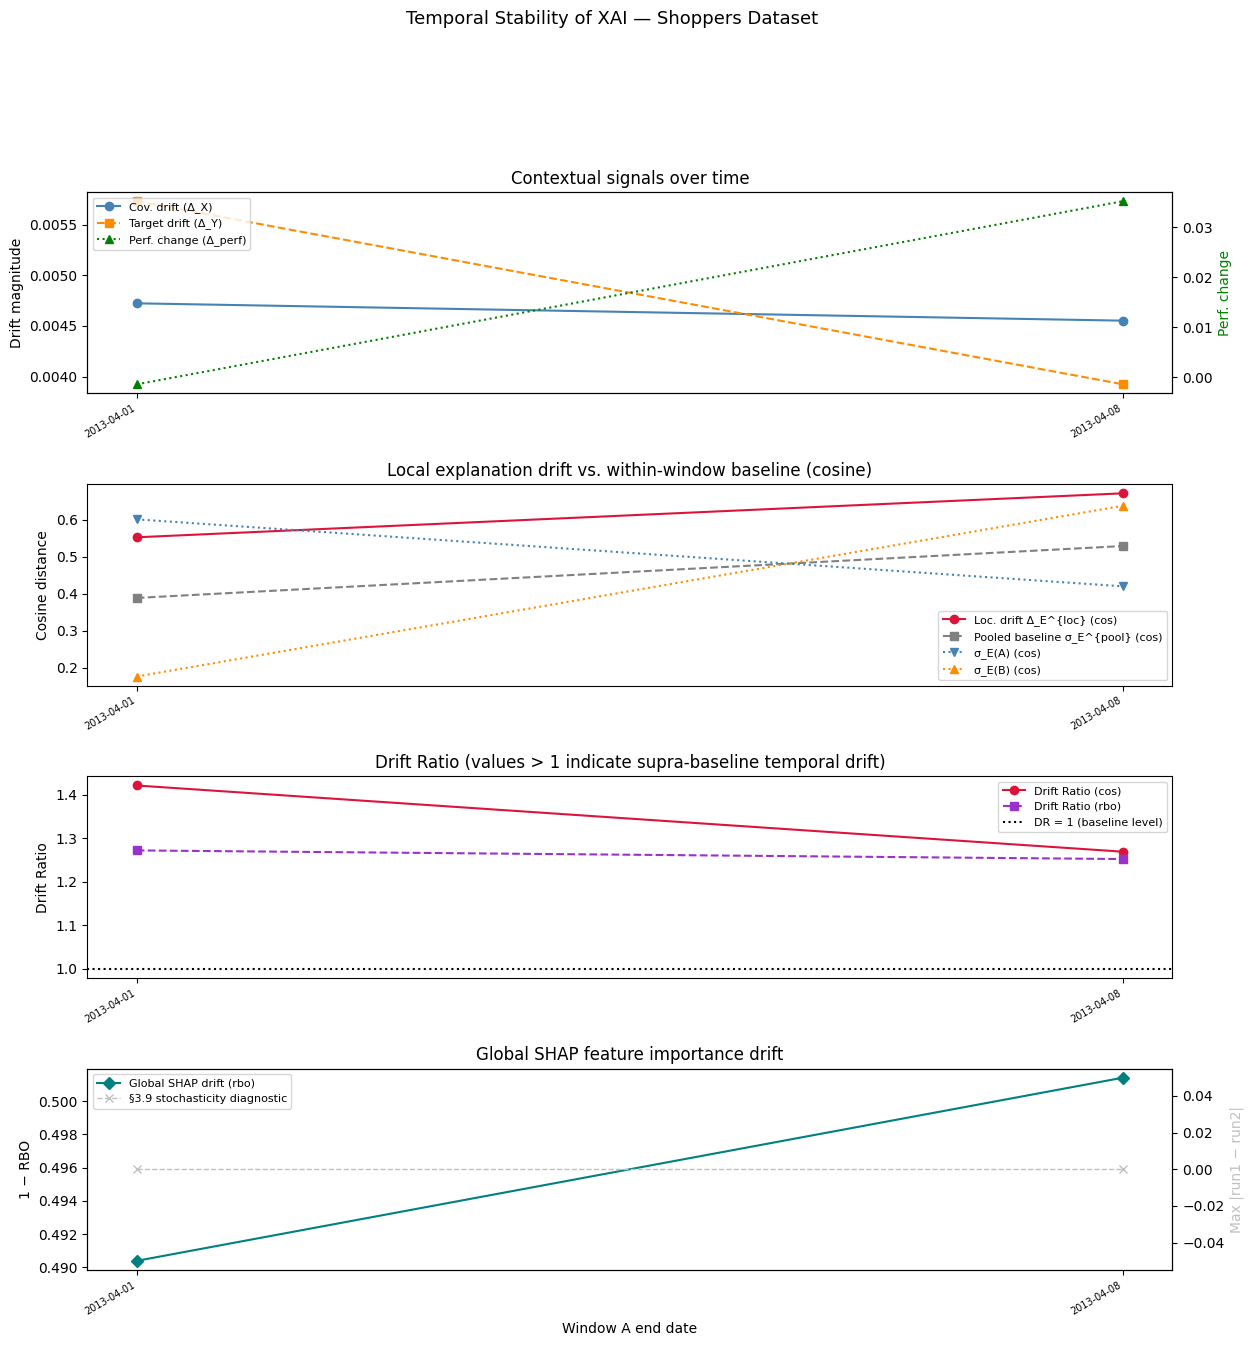

Figure saved.


In [ ]:
df_all = combined_df.copy()
df_all = df_all.dropna(subset=['loc_cos'])

pair_ids = sorted(df_all['pair_id'].unique())
x_idx    = list(range(len(pair_ids)))

# x-axis labels from XGBoost rows (step_label_A), or first available model type
_ref_mt = next((mt for mt in MODEL_TYPES if mt in df_all['model_type'].values), MODEL_TYPES[0])
_ref_df = df_all[df_all['model_type'] == _ref_mt].sort_values('pair_id')
x_labels = list(_ref_df['step_label_A'])

COLORS  = {'xgboost': 'crimson',  'logreg': 'steelblue'}
MARKERS = {'xgboost': 'o',         'logreg': 's'}
LINES   = {'xgboost': '-',         'logreg': '--'}

fig = plt.figure(figsize=(14, 14))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

# ── Panel 1: contextual signals ────────────────────────────────────────
ax1  = fig.add_subplot(gs[0])
ax1b = ax1.twinx()
df0 = df_all[df_all['model_type'] == _ref_mt].sort_values('pair_id')
ax1.plot(x_idx, df0['delta_X'].values,    'o-',  color='steelblue',  label='Cov. drift (Δ_X)')
ax1.plot(x_idx, df0['delta_Y'].values,    's--', color='darkorange', label='Target drift (Δ_Y)')
for mt in MODEL_TYPES:
    dft = df_all[df_all['model_type'] == mt].sort_values('pair_id')
    if dft.empty: continue
    ax1b.plot(x_idx, dft['delta_perf'].values,
              f'{MARKERS[mt]}:', color=COLORS[mt], label=f'Δ_perf ({mt})')
ax1.set_ylabel('Drift magnitude')
ax1b.set_ylabel('Perf. change')
ax1.set_title('Contextual signals over time')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper left', fontsize=8)
ax1.set_xticks(x_idx); ax1.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=7)

# ── Panel 2: local drift vs baselines ─────────────────────────────────
ax2 = fig.add_subplot(gs[1])
for mt in MODEL_TYPES:
    dft = df_all[df_all['model_type'] == mt].sort_values('pair_id')
    if dft.empty: continue
    ax2.plot(x_idx, dft['loc_cos'].values,
             f'{MARKERS[mt]}{LINES[mt]}', color=COLORS[mt],
             label=f'Loc. drift ({mt})')
    ax2.plot(x_idx, dft['sigma_cos'].values,
             f'{MARKERS[mt]}:', color=COLORS[mt], alpha=0.5,
             label=f'Baseline σ_E^{{pool}} ({mt})')
ax2.set_ylabel('Cosine distance')
ax2.set_title('Local explanation drift vs. within-window baseline (cosine)')
ax2.legend(fontsize=7)
ax2.set_xticks(x_idx); ax2.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=7)

# ── Panel 3: drift ratios ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
for mt in MODEL_TYPES:
    dft = df_all[df_all['model_type'] == mt].sort_values('pair_id')
    if dft.empty: continue
    ax3.plot(x_idx, dft['drift_ratio_cos'].values,
             f'{MARKERS[mt]}{LINES[mt]}', color=COLORS[mt], label=f'DR cos ({mt})')
ax3.axhline(y=1.0, color='black', linestyle=':', linewidth=1.5, label='DR = 1 (baseline level)')
ax3.set_ylabel('Drift Ratio')
ax3.set_title('Drift Ratio (values > 1 indicate supra-baseline temporal drift)')
ax3.legend(fontsize=8)
ax3.set_xticks(x_idx); ax3.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=7)

# ── Panel 4: global drift + stochasticity diagnostic ──────────────────
ax4  = fig.add_subplot(gs[3])
ax4b = ax4.twinx()
for mt in MODEL_TYPES:
    dft = df_all[df_all['model_type'] == mt].sort_values('pair_id')
    if dft.empty: continue
    ax4.plot(x_idx, dft['global_rbo'].values,
             f'{MARKERS[mt]}{LINES[mt]}', color=COLORS[mt], label=f'Global drift ({mt})')
if 'xgboost' in df_all['model_type'].values:
    dft_xgb = df_all[df_all['model_type'] == 'xgboost'].sort_values('pair_id')
    ax4b.plot(x_idx, dft_xgb['shap_stochasticity'].values, 'x--',
              color='silver', linewidth=1, label='§3.9 stochasticity diagnostic')
ax4.set_ylabel('1 − RBO')
ax4b.set_ylabel('Max |run1 − run2|', color='silver')
ax4.set_title('Global feature importance drift')
lines4a, labs4a = ax4.get_legend_handles_labels()
lines4b, labs4b = ax4b.get_legend_handles_labels()
ax4.legend(lines4a + lines4b, labs4a + labs4b, loc='upper left', fontsize=8)
ax4.set_xticks(x_idx); ax4.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=7)
ax4.set_xlabel('Window A end date')

plt.suptitle('Temporal Stability of XAI — Shoppers Dataset (Combined)', fontsize=13, y=1.01)
plt.savefig(COMBINED_DIR / 'temporal_drift_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Combined dashboard saved.')

## Per-feature SHAP drift profile

Shows which features shift most in global importance across the timeline.

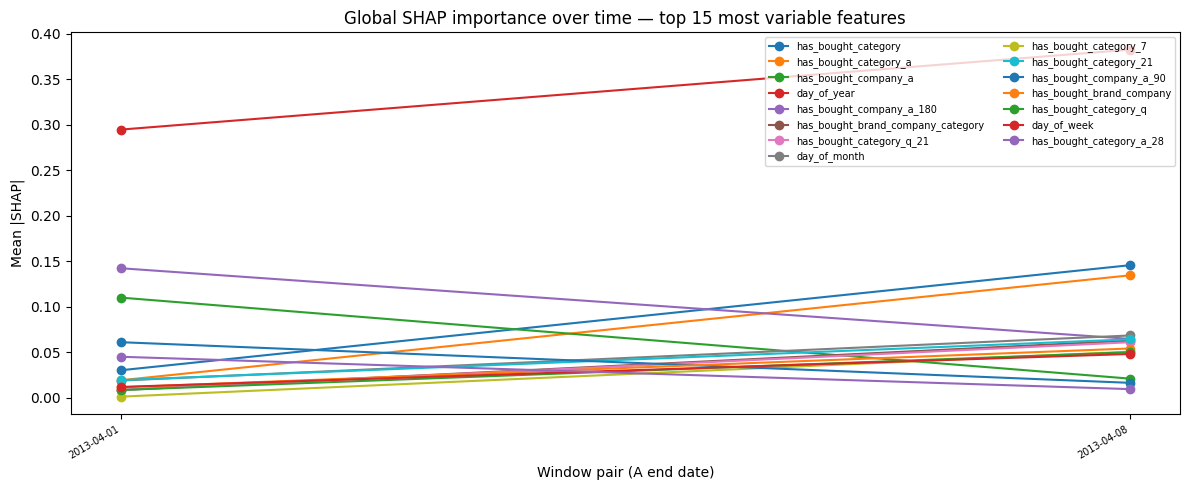

In [ ]:
# Collect global importance g_A for each pair
global_imp_matrix = []  # (n_pairs, n_features)
pair_labels = []

for p in pairs:
    pid      = p['pair_id']
    shap_dir = SHAP_DIR / f'pair_{pid:02d}'
    shap_A_path = shap_dir / 'shap_A.npy'
    if not shap_A_path.exists():
        continue
    shap_A = np.load(shap_A_path)        # (R, |F|, p)
    phi_bar_A = shap_A.mean(axis=0)      # (|F|, p)
    g_A = np.abs(phi_bar_A).mean(axis=0) # (p,)
    global_imp_matrix.append(g_A)
    pair_labels.append(p['step_label_A'])

if global_imp_matrix:
    imp_arr = np.array(global_imp_matrix)   # (n_pairs, p)

    # Top 15 most variable features across time
    feat_variance = imp_arr.std(axis=0)
    top_feat_idx = np.argsort(-feat_variance)[:15]

    fig, ax = plt.subplots(figsize=(12, 5))
    for j in top_feat_idx:
        ax.plot(range(len(pair_labels)), imp_arr[:, j], marker='o', label=feature_names[j], linewidth=1.5)
    ax.set_title('Global SHAP importance over time — top 15 most variable features')
    ax.set_xlabel('Window pair (A end date)')
    ax.set_ylabel('Mean |SHAP|')
    ax.set_xticks(range(len(pair_labels)))
    ax.set_xticklabels(pair_labels, rotation=30, ha='right', fontsize=7)
    ax.legend(loc='upper right', fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'feature_importance_over_time.png', dpi=150)
    plt.show()

## Summary statistics

In [ ]:
numeric_cols = [
    'pr_auc_A', 'pr_auc_B', 'delta_perf',
    'delta_X', 'delta_Y',
    'loc_cos', 'base_cos_A', 'base_cos_B', 'sigma_cos', 'drift_ratio_cos',
    'loc_rbo', 'base_rbo_A', 'base_rbo_B', 'sigma_rbo', 'drift_ratio_rbo',
    'global_rbo', 'shap_stochasticity'
]

for mt in MODEL_TYPES:
    if mt not in all_results or not all_results[mt]:
        continue
    mt_df = pd.DataFrame(all_results[mt])
    avail_cols = [c for c in numeric_cols if c in mt_df.columns]
    summary = mt_df[avail_cols].describe().T[['mean', 'std', 'min', 'max']]
    print(f'\n=== {mt} — overall summary ===')
    print(summary.round(4).to_string())

    dr_cos_mean = mt_df['drift_ratio_cos'].mean()
    print(f'\n  Mean Drift Ratio (cosine): {dr_cos_mean:.3f}')
    if dr_cos_mean > 2.0:
        print('  → Temporal explanation drift is substantially larger than retraining noise.')
    elif dr_cos_mean > 1.0:
        print('  → Temporal drift moderately exceeds retraining baseline.')
    else:
        print('  → Temporal drift is within the range of ordinary retraining noise.')

Overall summary:
                      mean     std     min     max
pr_auc_A            0.3930  0.0036  0.3904  0.3955
pr_auc_B            0.4098  0.0294  0.3890  0.4307
delta_perf          0.0169  0.0259 -0.0014  0.0352
delta_X             0.0046  0.0001  0.0046  0.0047
delta_Y             0.0048  0.0013  0.0039  0.0057
loc_cos             0.6124  0.0840  0.5530  0.6718
base_cos_A          0.5109  0.1280  0.4204  0.6014
base_cos_B          0.4075  0.3265  0.1767  0.6384
sigma_cos           0.4592  0.0992  0.3890  0.5294
drift_ratio_cos     1.3452  0.1077  1.2691  1.4214
loc_rbo             0.5620  0.0424  0.5320  0.5919
base_rbo_A          0.4808  0.0338  0.4569  0.5047
base_rbo_B          0.4102  0.1109  0.3318  0.4886
sigma_rbo           0.4455  0.0385  0.4182  0.4727
drift_ratio_rbo     1.2621  0.0140  1.2522  1.2720
global_rbo          0.4959  0.0078  0.4904  0.5014
shap_stochasticity  0.0000  0.0000  0.0000  0.0000

--- Interpretation ---
Mean Drift Ratio (cosine): 1.345
  → Temp